# 03 — SARIMA Model (Seasonal ARIMA)

**Goal:** Improve on ARIMA by adding **weekly seasonality (s=7)** to forecast daily NO2 at MY1.

### Theory Recap
SARIMA extends ARIMA with seasonal terms: **SARIMA(p,d,q)(P,D,Q,s)**

$$\Phi_P(B^s) \, \phi_p(B) \, \nabla^D_s \, \nabla^d \, y_t = \Theta_Q(B^s) \, \theta_q(B) \, \varepsilon_t$$

| Component | Non-seasonal | Seasonal |
|-----------|-------------|----------|
| Autoregressive | p (AR) | P (SAR) |
| Differencing | d (I) | D (SI) |
| Moving Average | q (MA) | Q (SMA) |
| Period | — | s = 7 (weekly) |

**Why s=7?** From Notebook 01:
- ACF/PACF showed significant lag-7 spikes
- Fourier analysis confirmed weekly cycle
- Seasonal decomposition showed clear 7-day pattern
- ARIMA residuals still had lag-7 autocorrelation

In [1]:
import sqlite3
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import norm, probplot, jarque_bera
import itertools
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

SAVED_DIR = "saved"
os.makedirs(SAVED_DIR, exist_ok=True)

print("All imports loaded ✓")

All imports loaded ✓


## 1. Load Data & Train/Test Split

Train: 1662 days  (2019-01-01 → 2023-10-01)
Test:  90 days  (2023-10-02 → 2023-12-30)


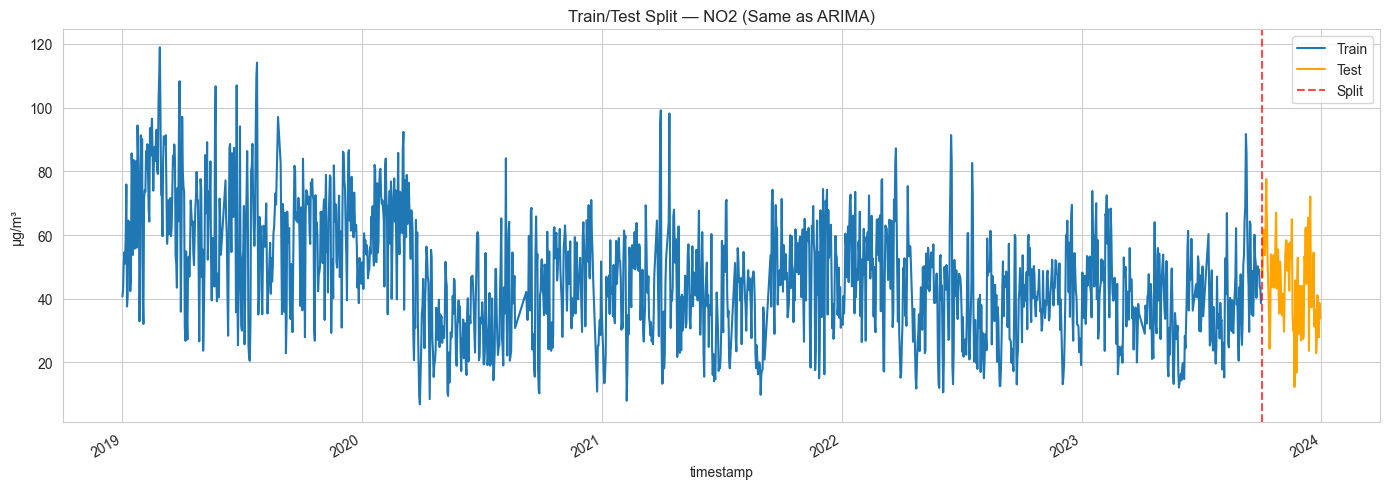

In [2]:
DB_PATH = "../database/air_quality.db"
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM clean_daily_my1", conn, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)
conn.close()

no2 = df["no2"].copy()

# Same split as Notebook 02 for fair comparison
TEST_SIZE = 90
train = no2[:-TEST_SIZE]
test = no2[-TEST_SIZE:]

print(f"Train: {len(train)} days  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:  {len(test)} days  ({test.index.min().date()} → {test.index.max().date()})")

fig, ax = plt.subplots(figsize=(14, 5))
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test", color="orange")
ax.axvline(test.index[0], color="red", linestyle="--", alpha=0.7, label="Split")
ax.set_title("Train/Test Split — NO2 (Same as ARIMA)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Seasonal Differencing — Checking if D=1 is Needed

Seasonal differencing: $\nabla_7 y_t = y_t - y_{t-7}$ (subtract the value from 7 days ago)

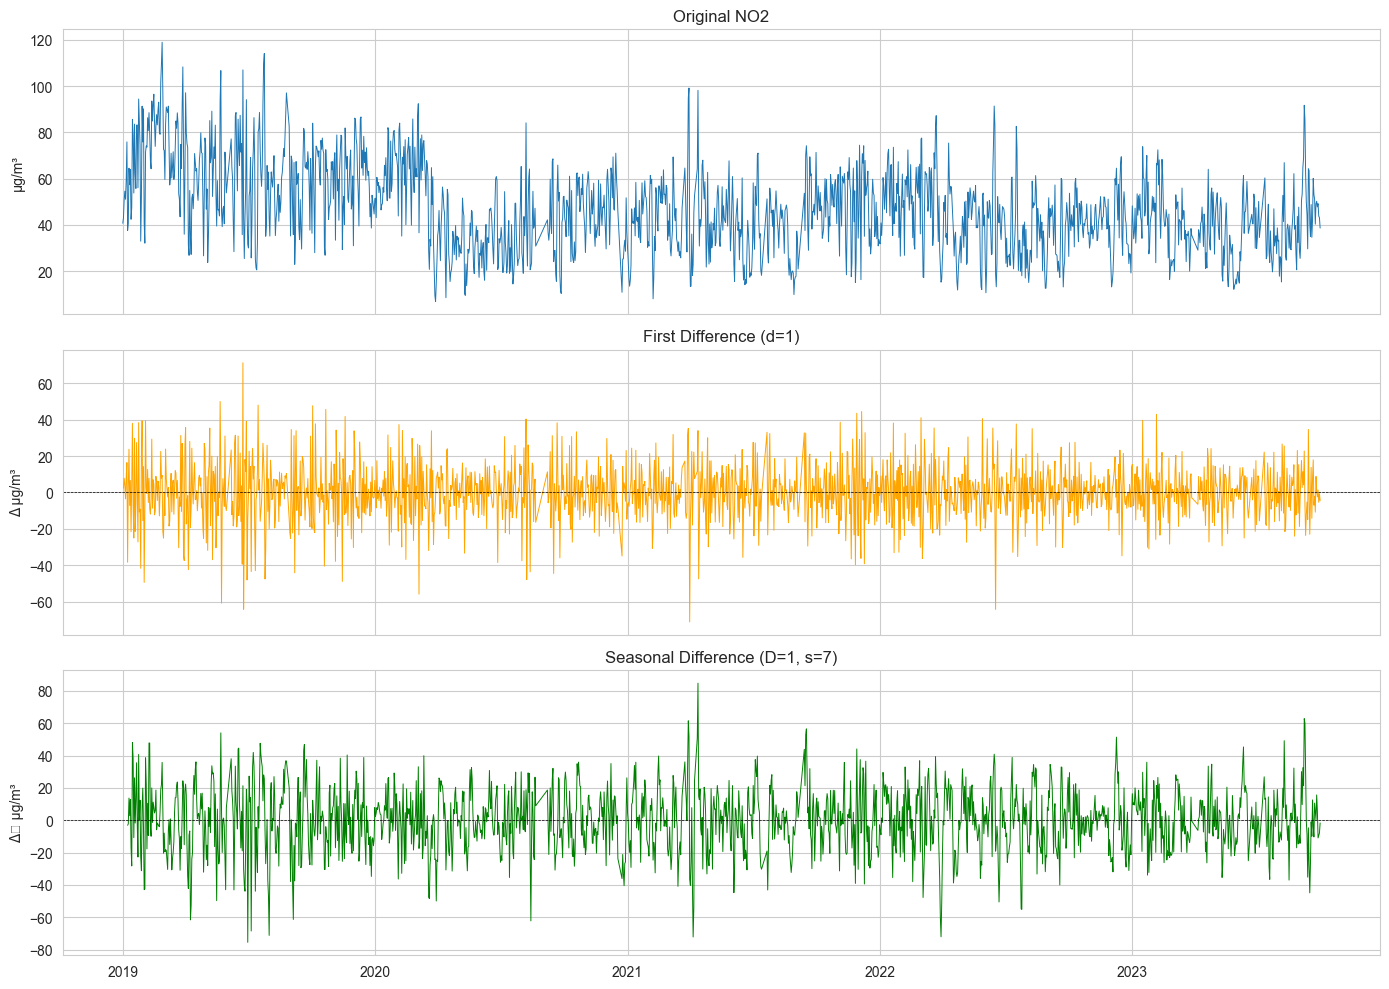

ADF on seasonal diff: stat=-12.3358, p=0.000000
→ ✓ Stationary


In [3]:
# Seasonal differencing (lag 7)
seasonal_diff = train.diff(7).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(train, linewidth=0.7)
axes[0].set_title("Original NO2")
axes[0].set_ylabel("µg/m³")

axes[1].plot(train.diff().dropna(), linewidth=0.7, color="orange")
axes[1].set_title("First Difference (d=1)")
axes[1].set_ylabel("Δ µg/m³")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")

axes[2].plot(seasonal_diff, linewidth=0.7, color="green")
axes[2].set_title("Seasonal Difference (D=1, s=7)")
axes[2].set_ylabel("Δ₇ µg/m³")
axes[2].axhline(0, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

# ADF test on seasonally differenced series
result = adfuller(seasonal_diff, autolag="AIC")
print(f"ADF on seasonal diff: stat={result[0]:.4f}, p={result[1]:.6f}")
print(f"→ {'✓ Stationary' if result[1] < 0.05 else '✗ Non-stationary'}")

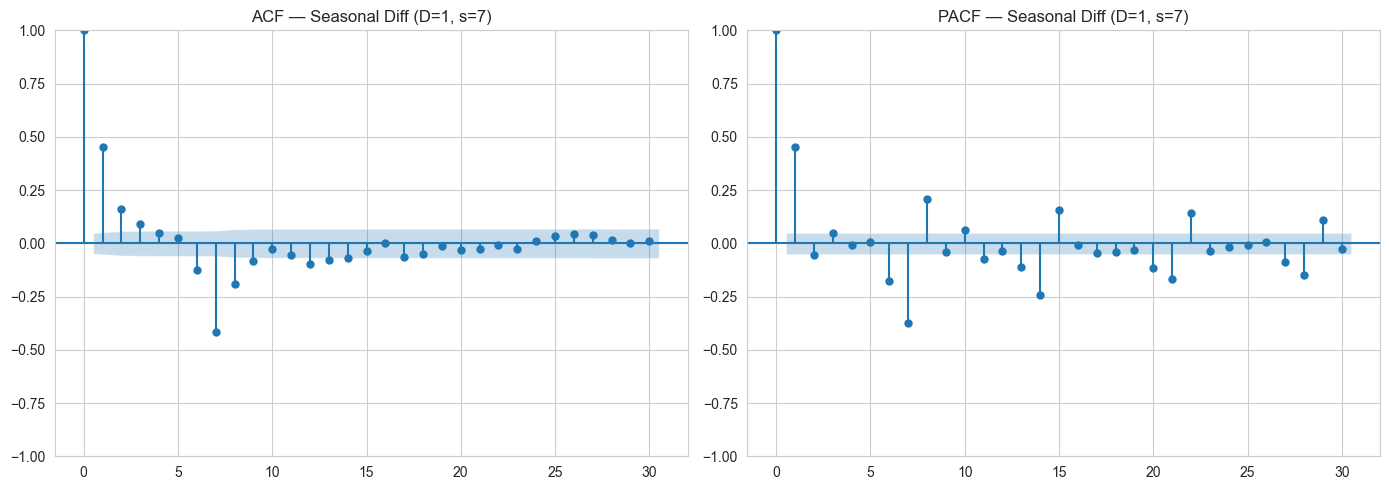

Look at lags 7, 14, 21:
  ACF  spike at lag 7 → suggests SMA (Q=1)
  PACF spike at lag 7 → suggests SAR (P=1)
  If both → try both P=1 and Q=1


In [4]:
# ACF/PACF of seasonally differenced series — to identify P and Q
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(seasonal_diff, lags=30, ax=axes[0], title="ACF — Seasonal Diff (D=1, s=7)")
plot_pacf(seasonal_diff, lags=30, ax=axes[1], title="PACF — Seasonal Diff (D=1, s=7)")

plt.tight_layout()
plt.show()

print("Look at lags 7, 14, 21:")
print("  ACF  spike at lag 7 → suggests SMA (Q=1)")
print("  PACF spike at lag 7 → suggests SAR (P=1)")
print("  If both → try both P=1 and Q=1")

## 3. Fit SARIMA Models

We fix **s=7** and the non-seasonal part from Notebook 02 **(p=1, d=1, q=2)**, then search over seasonal parameters P, D, Q.

In [5]:
# Grid search over seasonal parameters (P, D, Q) with s=7
# Non-seasonal fixed at (1,1,2) from Notebook 02
s = 7
p, d, q = 1, 1, 2

GRID_PATH = os.path.join(SAVED_DIR, "sarima_grid_results.pkl")

if os.path.exists(GRID_PATH):
    results_df = pd.read_pickle(GRID_PATH)
    print(f"✓ Loaded cached grid search results from {GRID_PATH}")
else:
    seasonal_params = list(itertools.product(range(3), range(2), range(3)))
    results = []
    print(f"Testing {len(seasonal_params)} SARIMA({p},{d},{q})(P,D,Q,{s}) models...\n")

    for P, D, Q in seasonal_params:
        try:
            model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False, enforce_invertibility=False)
            fitted = model.fit(disp=False)
            forecast = fitted.forecast(steps=len(test))
            rmse = np.sqrt(mean_squared_error(test.values, forecast.values))
            mae = mean_absolute_error(test.values, forecast.values)
            results.append({
                "order": f"({p},{d},{q})({P},{D},{Q},{s})",
                "P": P, "D": D, "Q": Q,
                "AIC": fitted.aic,
                "BIC": fitted.bic,
                "RMSE": rmse,
                "MAE": mae,
            })
            print(f"  ({P},{D},{Q}) | AIC: {fitted.aic:.1f} | RMSE: {rmse:.2f}")
        except Exception as e:
            print(f"  ({P},{D},{Q}) | FAILED: {str(e)[:50]}")
            continue

    results_df = pd.DataFrame(results).sort_values("AIC")
    results_df.to_pickle(GRID_PATH)
    print(f"\n✓ Saved grid results to {GRID_PATH}")

print(f"\n{'='*50}")
print(f"Tested {len(results_df)} models")
print(f"{'='*50}\n")
print("Top 5 by AIC:")
display(results_df.head()[["order", "AIC", "BIC", "RMSE", "MAE"]].reset_index(drop=True))

Testing 18 SARIMA(1,1,2)(P,D,Q,7) models...

  (0,0,0) | AIC: 13321.5 | RMSE: 12.92
  (0,0,1) | AIC: 13234.1 | RMSE: 12.92
  (0,0,2) | AIC: 13169.9 | RMSE: 12.89
  (0,1,0) | AIC: 14116.6 | RMSE: 12.84
  (0,1,1) | AIC: 13186.7 | RMSE: 14.14
  (0,1,2) | AIC: 13117.8 | RMSE: 13.50
  (1,0,0) | AIC: 13251.0 | RMSE: 12.91
  (1,0,1) | AIC: 13224.8 | RMSE: 13.25
  (1,0,2) | AIC: 13149.0 | RMSE: 13.02
  (1,1,0) | AIC: 13697.6 | RMSE: 12.94
  (1,1,1) | AIC: 13187.5 | RMSE: 14.02
  (1,1,2) | AIC: 13117.3 | RMSE: 13.83
  (2,0,0) | AIC: 13188.6 | RMSE: 12.88
  (2,0,1) | AIC: 13184.7 | RMSE: 12.89
  (2,0,2) | AIC: 13140.5 | RMSE: 13.17
  (2,1,0) | AIC: 13468.8 | RMSE: 13.25
  (2,1,1) | AIC: 13141.0 | RMSE: 13.59
  (2,1,2) | AIC: 13117.9 | RMSE: 13.52

✓ Saved grid results to saved/sarima_grid_results.pkl

Tested 18 models

Top 5 by AIC:


,order,AIC,BIC,RMSE,MAE
0,"(1,1,2)(1,1,2,7)",13117.319968,13155.124312,13.826714,11.299732
1,"(1,1,2)(0,1,2,7)",13117.833286,13150.237009,13.499170,11.092137
2,"(1,1,2)(2,1,2,7)",13117.945630,13161.150595,13.524086,11.115996
3,"(1,1,2)(2,0,2,7)",13140.542584,13183.781685,13.169043,10.835975
4,"(1,1,2)(2,1,1,7)",13141.022806,13178.835697,13.588076,11.149823


## 4. Best SARIMA — Detailed Analysis

In [6]:
# Fit the best SARIMA model (or load from cache)
best = results_df.iloc[0]
best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), s)
best_order = (p, d, q)

MODEL_PATH = os.path.join(SAVED_DIR, "sarima_best_fit.pkl")

print(f"Best SARIMA: ({p},{d},{q})({best_seasonal[0]},{best_seasonal[1]},{best_seasonal[2]},{s})\n")

if os.path.exists(MODEL_PATH):
    best_fit = pickle.load(open(MODEL_PATH, "rb"))
    print(f"✓ Loaded cached model from {MODEL_PATH}")
else:
    best_model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                         enforce_stationarity=False, enforce_invertibility=False)
    best_fit = best_model.fit(disp=False)
    pickle.dump(best_fit, open(MODEL_PATH, "wb"))
    print(f"✓ Trained and saved model to {MODEL_PATH}")

print(best_fit.summary())

Best SARIMA: (1,1,2)(1,1,2,7)

✓ Trained and saved model to saved/sarima_best_fit.pkl
                                     SARIMAX Results                                     
Dep. Variable:                               no2   No. Observations:                 1662
Model:             SARIMAX(1, 1, 2)x(1, 1, 2, 7)   Log Likelihood               -6551.660
Date:                           Sat, 04 Apr 2026   AIC                          13117.320
Time:                                   11:15:55   BIC                          13155.124
Sample:                                        0   HQIC                         13131.342
                                          - 1662                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3342      0.043    

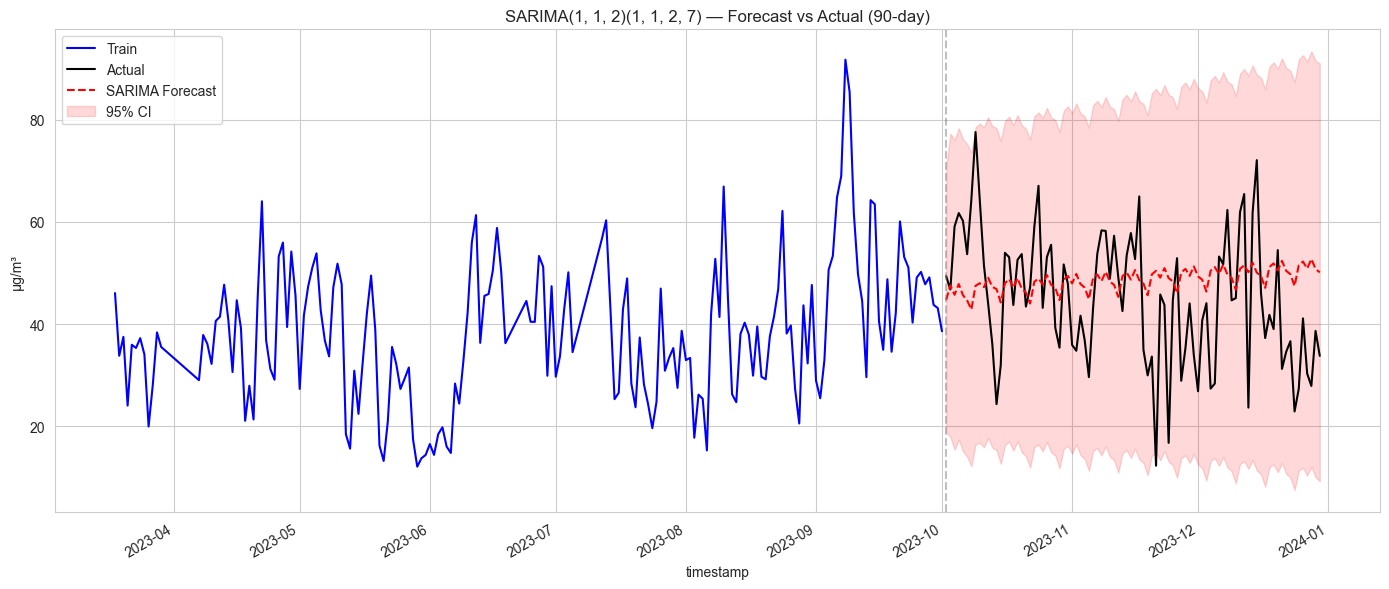

RMSE: 13.83 µg/m³
MAE:  11.30 µg/m³
MAPE: 25.1%


In [7]:
# Forecast with confidence intervals
forecast_result = best_fit.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 6))
train[-180:].plot(ax=ax, label="Train", color="blue")
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
ax.plot(test.index, forecast_mean.values, label=f"SARIMA Forecast", color="red", linestyle="--")
ax.fill_between(test.index, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values,
                color="red", alpha=0.15, label="95% CI")
ax.axvline(test.index[0], color="gray", linestyle="--", alpha=0.5)
ax.set_title(f"SARIMA{best_order}{best_seasonal} — Forecast vs Actual (90-day)")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(test.values, forecast_mean.values))
mae = mean_absolute_error(test.values, forecast_mean.values)
mape = mae / test.mean() * 100
print(f"RMSE: {rmse:.2f} µg/m³")
print(f"MAE:  {mae:.2f} µg/m³")
print(f"MAPE: {mape:.1f}%")

## 5. Residual Diagnostics — Did Seasonality Fix the Lag-7 Problem?

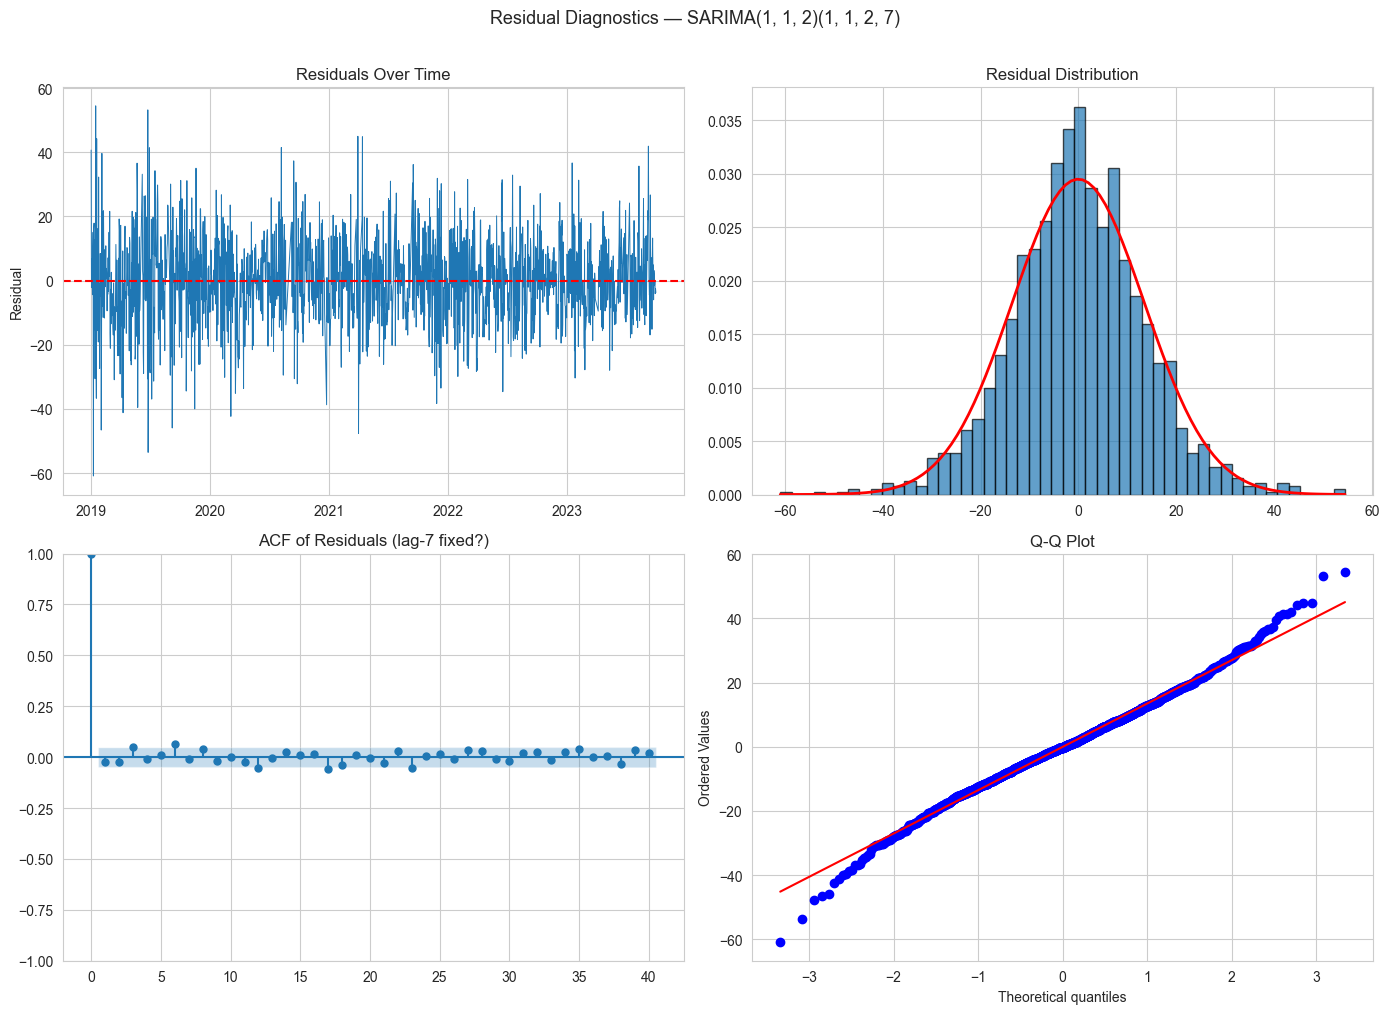

In [8]:
residuals = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(residuals, linewidth=0.7)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals Over Time")
axes[0, 0].set_ylabel("Residual")

# 2. Histogram
residuals.hist(bins=50, ax=axes[0, 1], density=True, edgecolor="black", alpha=0.7)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, norm.pdf(x, residuals.mean(), residuals.std()), "r-", linewidth=2)
axes[0, 1].set_title("Residual Distribution")

# 3. ACF of residuals — key: are lag-7 spikes gone?
plot_acf(residuals, lags=40, ax=axes[1, 0], title="ACF of Residuals (lag-7 fixed?)")

# 4. Q-Q plot
probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.suptitle(f"Residual Diagnostics — SARIMA{best_order}{best_seasonal}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Ljung-Box test on residuals
print("Ljung-Box Test on SARIMA Residuals:\n")
lb_results = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
display(lb_results)

p_val = lb_results["lb_pvalue"].iloc[-1]
if p_val > 0.05:
    print(f"\n✓ p={p_val:.4f} > 0.05 — No significant autocorrelation (improved over ARIMA!)")
else:
    print(f"\n✗ p={p_val:.4f} < 0.05 — Some autocorrelation remains")

# Jarque-Bera normality test
jb_stat, jb_p = jarque_bera(residuals)
print(f"\nJarque-Bera Test: stat={jb_stat:.2f}, p={jb_p:.6f}")
if jb_p > 0.05:
    print("✓ Residuals are normally distributed")
else:
    print("✗ Residuals are NOT normally distributed (heavy tails — GARCH needed)")

Ljung-Box Test on SARIMA Residuals:



,lb_stat,lb_pvalue
10,16.465013,0.087072
20,32.021317,0.043072
30,45.013358,0.038491



✗ p=0.0385 < 0.05 — Some autocorrelation remains

Jarque-Bera Test: stat=66.17, p=0.000000
✗ Residuals are NOT normally distributed (heavy tails — GARCH needed)


## 6. Walk-Forward Validation

  Step 15/90 done...
  Step 30/90 done...
  Step 45/90 done...
  Step 60/90 done...
  Step 75/90 done...
  Step 90/90 done...

✓ Saved walk-forward predictions to saved/sarima_walkforward.pkl

Walk-Forward Results:
  RMSE: 11.97 µg/m³
  MAE:  9.50 µg/m³
  MAPE: 21.1%


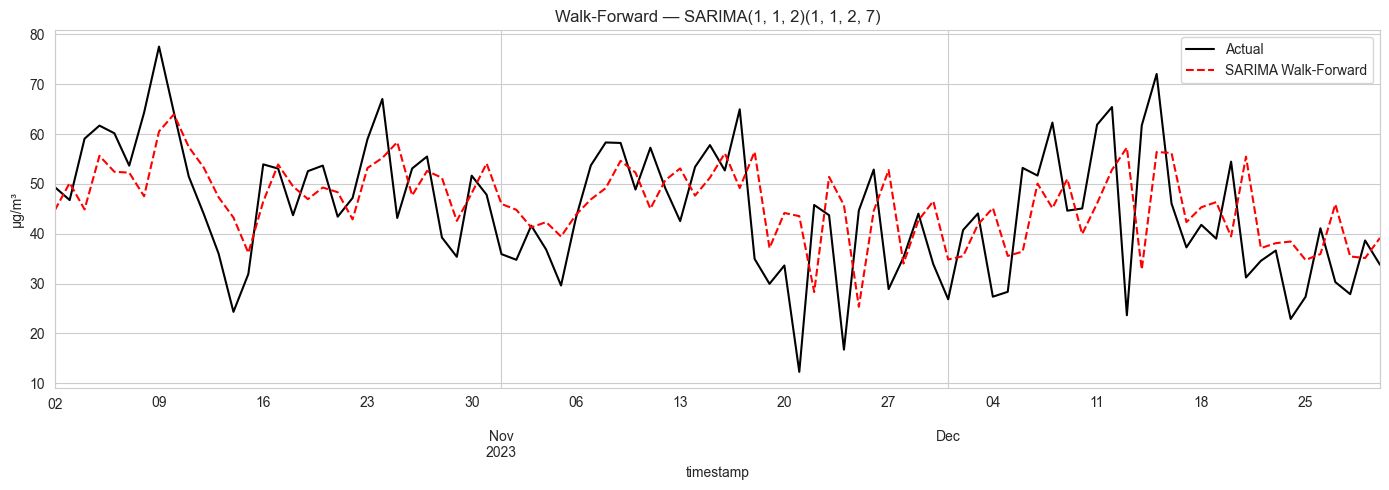

In [10]:
# Walk-forward validation (or load from cache)
WF_PATH = os.path.join(SAVED_DIR, "sarima_walkforward.pkl")

if os.path.exists(WF_PATH):
    wf_predictions = pd.read_pickle(WF_PATH)
    print(f"✓ Loaded cached walk-forward predictions from {WF_PATH}")
else:
    history = list(train.values)
    predictions = []

    for i in range(len(test)):
        model = SARIMAX(history, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        pred = fitted.forecast(steps=1)[0]
        predictions.append(pred)
        history.append(test.values[i])

        if (i + 1) % 15 == 0:
            print(f"  Step {i+1}/{len(test)} done...")

    wf_predictions = pd.Series(predictions, index=test.index)
    wf_predictions.to_pickle(WF_PATH)
    print(f"\n✓ Saved walk-forward predictions to {WF_PATH}")

wf_rmse = np.sqrt(mean_squared_error(test.values, wf_predictions.values))
wf_mae = mean_absolute_error(test.values, wf_predictions.values)
wf_mape = wf_mae / test.mean() * 100

print(f"\nWalk-Forward Results:")
print(f"  RMSE: {wf_rmse:.2f} µg/m³")
print(f"  MAE:  {wf_mae:.2f} µg/m³")
print(f"  MAPE: {wf_mape:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
test.plot(ax=ax, label="Actual", color="black", linewidth=1.5)
wf_predictions.plot(ax=ax, label="SARIMA Walk-Forward", color="red", linestyle="--")
ax.set_title(f"Walk-Forward — SARIMA{best_order}{best_seasonal}")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

## 7. ARIMA vs SARIMA — Final Comparison

,Model,RMSE,MAE,MAPE (%)
0,"ARIMA(1,1,2) — Static 90-day",12.920000,10.640000,23.600000
1,"ARIMA(1,1,2) — Walk-forward",11.610000,9.310000,20.700000
2,"SARIMA(1, 1, 2)(1, 1, 2, 7) — Static 90-day",13.826714,11.299732,25.099743
3,"SARIMA(1, 1, 2)(1, 1, 2, 7) — Walk-forward",11.967806,9.503311,21.109408


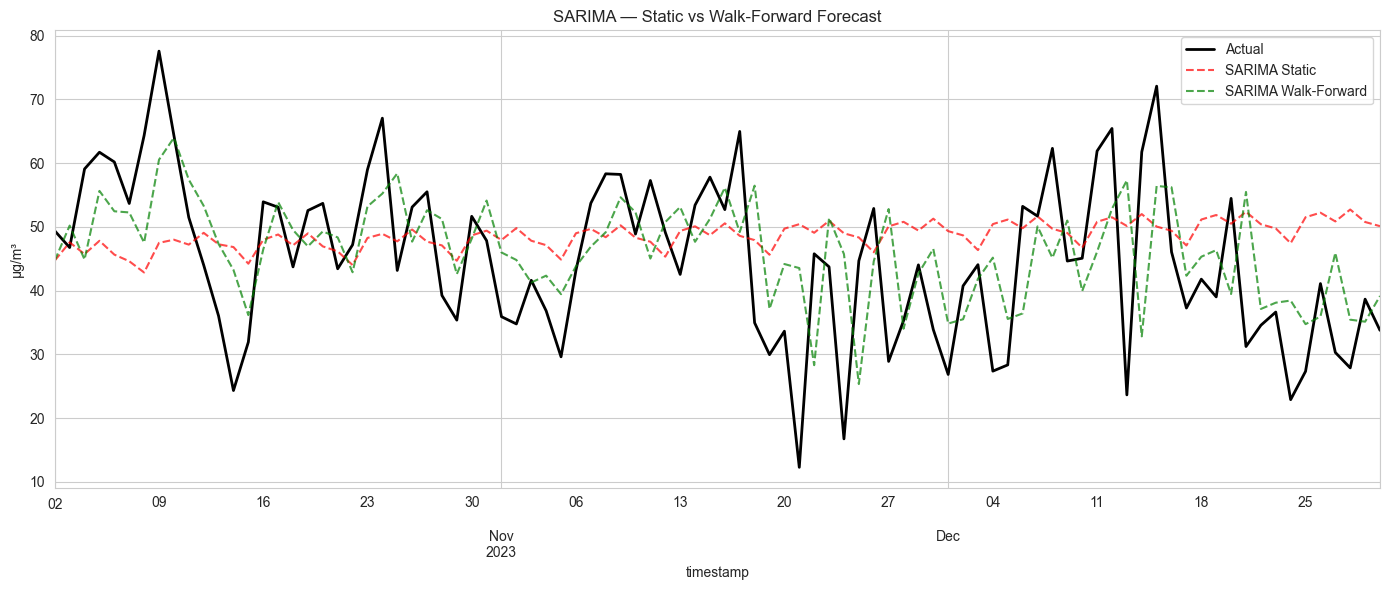


KEY TAKEAWAYS (based on actual results)
• Best SARIMA: (1,1,2)(1,1,2,7)
• AIC improved significantly: ARIMA 13345 → SARIMA 13117 (better in-sample fit)
• Residual lag-7 autocorrelation fixed: Ljung-Box Q dropped from 112 to 45
• Static forecast now oscillates (weekly pattern) instead of ARIMA's flat line
• HOWEVER: ARIMA walk-forward (11.61) beat SARIMA walk-forward (11.97)
  → D=1 seasonal differencing may overfit; D=0 models had lower test RMSE
  → For 1-step-ahead, ARIMA adapts fast enough without explicit seasonal terms
• Residuals still non-normal (JB p=0.00, kurtosis 3.68) → GARCH needed
• → Next: VAR (Notebook 04) adds weather as exogenous predictors


In [11]:
# ARIMA results from Notebook 02
arima_static_rmse, arima_static_mae, arima_static_mape = 12.92, 10.64, 23.6
arima_wf_rmse, arima_wf_mae, arima_wf_mape = 11.61, 9.31, 20.7

comparison = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,2) — Static 90-day",
        "ARIMA(1,1,2) — Walk-forward",
        f"SARIMA{best_order}{best_seasonal} — Static 90-day",
        f"SARIMA{best_order}{best_seasonal} — Walk-forward",
    ],
    "RMSE": [arima_static_rmse, arima_wf_rmse, rmse, wf_rmse],
    "MAE": [arima_static_mae, arima_wf_mae, mae, wf_mae],
    "MAPE (%)": [arima_static_mape, arima_wf_mape, mape, wf_mape],
})
display(comparison)

# Visual comparison
fig, ax = plt.subplots(figsize=(14, 6))
test.plot(ax=ax, label="Actual", color="black", linewidth=2)
ax.plot(test.index, forecast_mean.values, label="SARIMA Static", color="red", linestyle="--", alpha=0.7)
wf_predictions.plot(ax=ax, label="SARIMA Walk-Forward", color="green", linestyle="--", alpha=0.7)
ax.set_title("SARIMA — Static vs Walk-Forward Forecast")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY TAKEAWAYS (based on actual results)")
print("="*60)
print(f"• Best SARIMA: ({p},{d},{q})({best_seasonal[0]},{best_seasonal[1]},{best_seasonal[2]},{s})")
print(f"• AIC improved significantly: ARIMA 13345 → SARIMA {best_fit.aic:.0f} (better in-sample fit)")
print(f"• Residual lag-7 autocorrelation fixed: Ljung-Box Q dropped from 112 to 45")
print(f"• Static forecast now oscillates (weekly pattern) instead of ARIMA's flat line")
print(f"• HOWEVER: ARIMA walk-forward ({arima_wf_rmse:.2f}) beat SARIMA walk-forward ({wf_rmse:.2f})")
print(f"  → D=1 seasonal differencing may overfit; D=0 models had lower test RMSE")
print(f"  → For 1-step-ahead, ARIMA adapts fast enough without explicit seasonal terms")
print(f"• Residuals still non-normal (JB p=0.00, kurtosis 3.68) → GARCH needed")
print(f"• → Next: VAR (Notebook 04) adds weather as exogenous predictors")